In [1]:
# Open count stores and run Scarf analyses.
import scarf

# Keep routine logs and progress bars out of the results.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_10K_pbmc-v1_atacseq",
    destination="scarf_datasets",
    zarr=True,
)
# Open the count store for this analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", default_assay="ATAC", nthreads=4)
# Inspect the opened store's cells and features.
ds

Downloading bucket files: 509414486 / 509414486 complete

Downloading bytes: 509414486 / 509414486 complete

DataStore has 8426 (8728) cells with 1 assays: ATAC
   Cell metadata:
            'I', 'ids', 'names', 'ATAC_UMAP1', 'ATAC_UMAP2', 
            'ATAC_leiden_cluster', 'ATAC_nCounts', 'ATAC_nFeatures'
   ATAC assay has 89796 features and following metadata:
            'I', 'ids', 'names', 'derivation', 'dropOuts', 
            'feature_type', 'genome', 'nCells'

In [2]:
# Select the saved ATAC clusters; require exactly one match.
[clusters] = ds.list_artifacts(
    from_assay="ATAC",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    complete_only=True,
)
# Select the saved ATAC UMAP; require exactly one match.
[umap] = ds.list_artifacts(
    from_assay="ATAC",
    kind="embedding",
    operation="run_umap",
    complete_only=True,
)
# Inspect the saved ATAC clustering and layout.
{"clusters": clusters, "UMAP": umap}

{'clusters': ArtifactRef(assay='ATAC', kind='cluster_labels', artifact_id='927d63b5dc46...'),
 'UMAP': ArtifactRef(assay='ATAC', kind='embedding', artifact_id='0e776203d155...')}

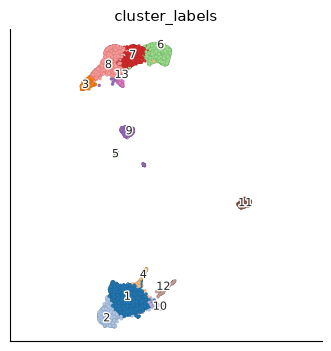

In [3]:
# Locate the ATAC clusters before interpreting their markers.
ds.plots.embedding(layout=umap, color_by=clusters, legend_loc='on_data')

In [4]:
# Download gene intervals for the dataset's reference genome.
annotations = scarf.cytebase.connect("scarf_docs").download_dataset(
    "annotations",
    destination="scarf_datasets",
)
# Combine peaks overlapping gene intervals into GeneScores.
ds.add_melded_assay(
    from_assay="ATAC",
    external_bed_fn=f"{annotations}/human_GRCh37_gencode_v38_gene_body.bed.gz",
    renormalization=False,
    assay_label="GeneScores",
    assay_type="RNA",
)
# Inspect the opened store's cells and features.
ds

Downloading bucket files: 4397159 / 4397159 complete

Downloading bytes: 4397159 / 4397159 complete

DataStore has 8426 (8728) cells with 2 assays: ATAC GeneScores
   Cell metadata:
            'I', 'ids', 'names', 'ATAC_UMAP1', 'ATAC_UMAP2', 
            'ATAC_leiden_cluster', 'ATAC_nCounts', 'ATAC_nFeatures', 'GeneScores_nCounts', 'GeneScores_nFeatures', 
            'GeneScores_percentMito', 'GeneScores_percentRibo'
   ATAC assay has 89796 features and following metadata:
            'I', 'ids', 'names', 'derivation', 'dropOuts', 
            'feature_type', 'genome', 'nCells'
   GeneScores assay has 62446 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'

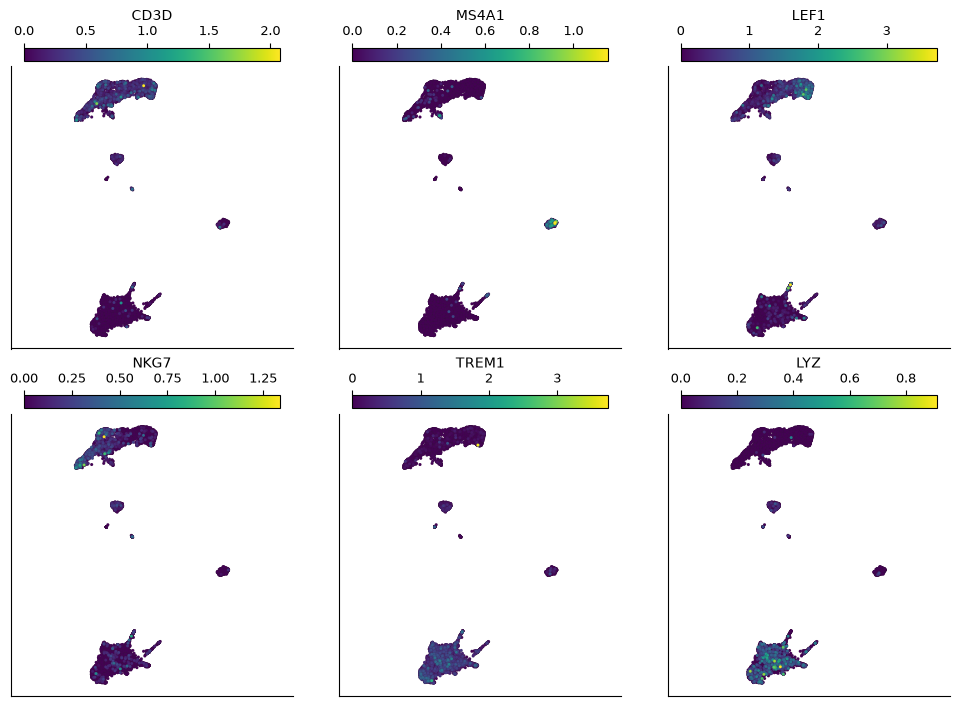

In [5]:
# Compare GeneScores for lymphoid and myeloid markers.
ds.plots.embedding(
    layout=umap,
    from_assay="GeneScores",
    color_by=["CD3D", "MS4A1", "LEF1", "NKG7", "TREM1", "LYZ"],
    n_columns=3,
    sort_values=True,
)